# **Model: CNN**

**1. SETUP & GPU CHECK**

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import glob
import zipfile
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
    print("CNN will use GPU.")
else:
    print("WARNING: No GPU detected.")

TensorFlow version: 2.20.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CNN will use GPU.


**2. Upload Data**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving CIC-IDS2017.zip to CIC-IDS2017.zip


**3. Extract Dataset**

In [3]:
zip_path = "/content/CIC-IDS2017.zip"
extract_path = "/content/CIC-IDS2017"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

parquet_files = glob.glob(
    f"{extract_path}/**/*.parquet",
    recursive=True
)

print(f"Found {len(parquet_files)} parquet files.")

for file in parquet_files:
    print(os.path.basename(file))

Found 8 parquet files.
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
DDoS-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
Benign-Monday-no-metadata.parquet


**4. Load Dataset**

In [4]:
dataframes = []

for file in parquet_files:
    print("Loading:", os.path.basename(file))
    temp_df = pd.read_parquet(file)
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

del dataframes

print("\nCombined dataset shape:", df.shape)
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))

Loading: Infiltration-Thursday-no-metadata.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: DDoS-Friday-no-metadata.parquet
Loading: WebAttacks-Thursday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet
Loading: Benign-Monday-no-metadata.parquet

Combined dataset shape: (2313810, 78)
Rows: 2,313,810
Columns: 78


**5. Cleaning Data**

In [5]:
print("Original shape:", df.shape)

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
duplicates_removed = before - len(df)

print(f"Duplicates removed: {duplicates_removed:,}")
print("Shape after deduplication:", df.shape)

# Replace infinity values
df = df.replace([np.inf, -np.inf], np.nan)

missing_before = df.isna().sum().sum()
print(f"Missing/invalid values before dropna: {missing_before:,}")

# Remove invalid rows
df = df.dropna().reset_index(drop=True)

print("Final cleaned shape:", df.shape)

Original shape: (2313810, 78)
Duplicates removed: 82,004
Shape after deduplication: (2231806, 78)
Missing/invalid values before dropna: 0
Final cleaned shape: (2231806, 78)


**6. Verifying Labels**

In [6]:
df["Label"] = df["Label"].astype(str).str.strip()

print(df["Label"].value_counts())

Label
Benign                        1895314
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [8]:
print("Unique labels:")
print(df["Label"].value_counts())

print("\nFirst 20 raw representations:")
for label in df["Label"].unique()[:20]:
    print(repr(label))

Unique labels:
Label
Benign                        1895314
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

First 20 raw representations:
'Benign'
'Infiltration'
'PortScan'
'DoS slowloris'
'DoS Slowhttptest'
'DoS Hulk'
'DoS GoldenEye'
'Heartbleed'
'FTP-Patator'
'SSH-Patator'
'DDoS'
'Web Attack � Brute Force'
'Web Attack � XSS'
'Web Attack � Sql Injection'
'Bot'


**7. Binary Target**

In [9]:
# Normalize labels to avoid case/spacing issues
df["Label"] = df["Label"].astype(str).str.strip()

# Binary classification
df["Target"] = (
    df["Label"].str.lower() != "benign"
).astype(np.int8)

print("Binary target distribution:")
print(df["Target"].value_counts())

print("\nPercentages:")
print(df["Target"].value_counts(normalize=True) * 100)

Binary target distribution:
Target
0    1895314
1     336492
Name: count, dtype: int64

Percentages:
Target
0    84.922883
1    15.077117
Name: proportion, dtype: float64


**8. Train/Test Split 80/20**

In [10]:
X = df.drop(columns=["Label", "Target"])
y = df["Target"]

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Features:", X.shape[1])
print("Non-numeric features:", non_numeric)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain samples:", f"{len(X_train):,}")
print("Test samples :", f"{len(X_test):,}")

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Features: 77
Non-numeric features: []

Train samples: 1,785,444
Test samples : 446,362

Train distribution:
Target
0    1516251
1     269193
Name: count, dtype: int64

Test distribution:
Target
0    379063
1     67299
Name: count, dtype: int64


**9. Standardize Features**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)

# Use same scaler on test data
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)

print("Training shape:", X_train_scaled.shape)
print("Test shape    :", X_test_scaled.shape)

print("\nTraining dtype:", X_train_scaled.dtype)
print("Test dtype    :", X_test_scaled.dtype)

print("\nNaN train:", np.isnan(X_train_scaled).sum())
print("NaN test :", np.isnan(X_test_scaled).sum())
print("Inf train:", np.isinf(X_train_scaled).sum())
print("Inf test :", np.isinf(X_test_scaled).sum())

Training shape: (1785444, 77)
Test shape    : (446362, 77)

Training dtype: float32
Test dtype    : float32

NaN train: 0
NaN test : 0
Inf train: 0
Inf test : 0


**10. 1D CNN Architecture**

In [12]:
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print("CNN training shape:", X_train_cnn.shape)
print("CNN test shape    :", X_test_cnn.shape)

CNN training shape: (1785444, 77, 1)
CNN test shape    : (446362, 77, 1)


**11. Class Weights**

In [13]:

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np.astype(int)
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights:")
print("BENIGN:", class_weights[0])
print("ATTACK:", class_weights[1])

Class weights:
BENIGN: 0.5887692736888549
ATTACK: 3.3162897995118743


**12. Building Sentinel CNN v1**

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

cnn_model = Sequential([
    Input(shape=(77, 1)),

    Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=256,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 77, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 77, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 19, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,529 (650.50 KB)

 Trainable params: 165,633 (647.00 KB)

 Non-trainable params: 896 (3.50 KB)

**13. Training Callbacks**

In [15]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

checkpoint_path = "/content/sentinel_cnn_binary_v1_best.keras"

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks ready.")
print("Best model will be saved to:", checkpoint_path)

Callbacks ready.
Best model will be saved to: /content/sentinel_cnn_binary_v1_best.keras


**14. CNN Training**

In [16]:
start_time = time.time()

history = cnn_model.fit(
    X_train_cnn,
    y_train_np,

    validation_split=0.10,

    epochs=30,
    batch_size=1024,

    class_weight=class_weights,
    callbacks=callbacks,

    verbose=1
)

training_time = time.time() - start_time

print("\nCNN training complete.")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")
print(f"Epochs completed: {len(history.history['loss'])}")

Epoch 1/30
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9564 - loss: 0.1077 - precision: 0.8054 - recall: 0.9515
Epoch 1: val_loss improved from None to 0.06363, saving model to /content/sentinel_cnn_binary_v1_best.keras

Epoch 1: finished saving model to /content/sentinel_cnn_binary_v1_best.keras
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9701 - loss: 0.0699 - precision: 0.8519 - recall: 0.9708 - val_accuracy: 0.9690 - val_loss: 0.0636 - val_precision: 0.8355 - val_recall: 0.9882 - learning_rate: 0.0010
Epoch 2/30
1569/1570 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9817 - loss: 0.0397 - precision: 0.9017 - recall: 0.9862
Epoch 2: val_loss did not improve from 0.06363
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9831 - loss: 0.0380 - precision: 0.9092 - recall: 0.9865 - val_accuracy: 0.9276 - val_loss: 0.6704 - val_precision: 0.9965 - val_recall: 0.5204 - learning_rate: 0.0010
Epoch 3/30
1569/1570 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accu

**14. Loading CNN Checkpoints**

In [17]:
best_cnn_model = tf.keras.models.load_model(
    "/content/sentinel_cnn_binary_v1_best.keras"
)

print("Best CNN checkpoint loaded.")

Best CNN checkpoint loaded.


**15. Full Test Set Prediction**

In [18]:
start_time = time.time()

y_prob_cnn = best_cnn_model.predict(
    X_test_cnn,
    batch_size=4096,
    verbose=1
).ravel()

prediction_time = time.time() - start_time

# Default binary threshold
y_pred_cnn = (y_prob_cnn >= 0.5).astype(np.int8)

print("\nFull CNN prediction complete.")
print(f"Test samples: {len(y_test_np):,}")
print(f"Prediction time: {prediction_time:.2f} seconds")

109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step

Full CNN prediction complete.
Test samples: 446,362
Prediction time: 5.60 seconds


**16. Test Metrics**

In [19]:
cnn_accuracy = accuracy_score(y_test_np, y_pred_cnn)
cnn_precision = precision_score(y_test_np, y_pred_cnn)
cnn_recall = recall_score(y_test_np, y_pred_cnn)
cnn_f1 = f1_score(y_test_np, y_pred_cnn)

print("=== Sentinel CNN v1 — FULL TEST DATASET ===")
print(f"Accuracy : {cnn_accuracy:.6f}")
print(f"Precision: {cnn_precision:.6f}")
print(f"Recall   : {cnn_recall:.6f}")
print(f"F1 Score : {cnn_f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_np,
        y_pred_cnn,
        target_names=["BENIGN", "ATTACK"],
        digits=6
    )
)

=== Sentinel CNN v1 — FULL TEST DATASET ===
Accuracy : 0.992450
Precision: 0.980272
Recall   : 0.969435
F1 Score : 0.974823

Classification Report:
              precision    recall  f1-score   support

      BENIGN   0.994584  0.996536  0.995559    379063
      ATTACK   0.980272  0.969435  0.974823     67299

    accuracy                       0.992450    446362
   macro avg   0.987428  0.982986  0.985191    446362
weighted avg   0.992426  0.992450  0.992433    446362



**17. Confusion Matrix**

True Negatives : 377750
False Positives: 1313
False Negatives: 2057
True Positives : 65242

False Positive Rate: 0.003464
False Negative Rate: 0.030565


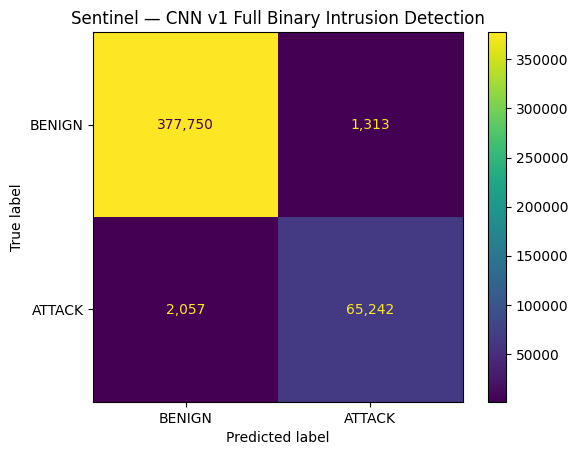

In [20]:
cm_cnn = confusion_matrix(y_test_np, y_pred_cnn)

tn, fp, fn, tp = cm_cnn.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print(f"\nFalse Positive Rate: {fp/(fp+tn):.6f}")
print(f"False Negative Rate: {fn/(fn+tp):.6f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format=",")
plt.title("Sentinel — CNN v1 Full Binary Intrusion Detection")
plt.show()

**18. Results in Dataframes**

In [21]:
cnn_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        fp / (fp + tn),
        fn / (fn + tp)
    ]
})

cnn_confusion_df = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=["Actual BENIGN", "Actual ATTACK"],
    columns=["Predicted BENIGN", "Predicted ATTACK"]
)

cnn_report_df = pd.DataFrame(
    classification_report(
        y_test_np,
        y_pred_cnn,
        target_names=["BENIGN", "ATTACK"],
        output_dict=True
    )
).transpose()

print("CNN Metrics:")
display(cnn_metrics_df)

print("\nCNN Confusion Matrix:")
display(cnn_confusion_df)

print("\nCNN Classification Report:")
display(cnn_report_df)

CNN Metrics:


,Metric,Value
0,Accuracy,0.992450
1,Precision,0.980272
2,Recall,0.969435
3,F1 Score,0.974823
4,False Positive Rate,0.003464
5,False Negative Rate,0.030565



CNN Confusion Matrix:


,Predicted BENIGN,Predicted ATTACK
Actual BENIGN,377750,1313
Actual ATTACK,2057,65242



CNN Classification Report:


,precision,recall,f1-score,support
BENIGN,0.994584,0.996536,0.995559,379063.00000
ATTACK,0.980272,0.969435,0.974823,67299.00000
accuracy,0.992450,0.992450,0.992450,0.99245
macro avg,0.987428,0.982986,0.985191,446362.00000
weighted avg,0.992426,0.992450,0.992433,446362.00000


**19. Training and Validation Loss**

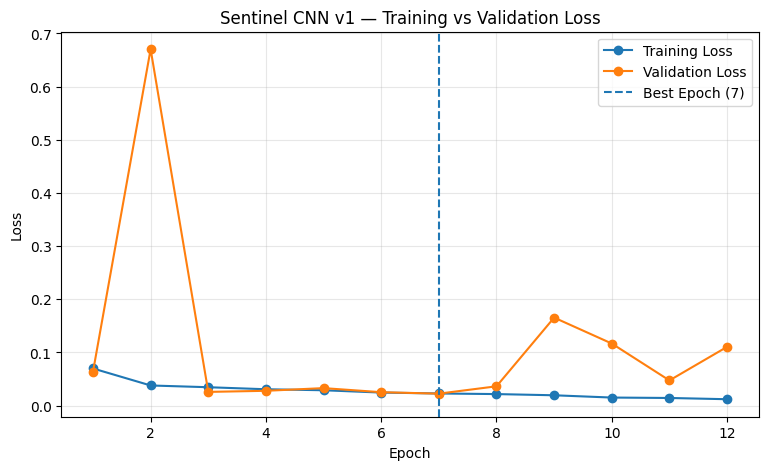

In [22]:
epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=7,
    linestyle="--",
    label="Best Epoch (7)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentinel CNN v1 — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**20. Training and Validation Acccuracy**

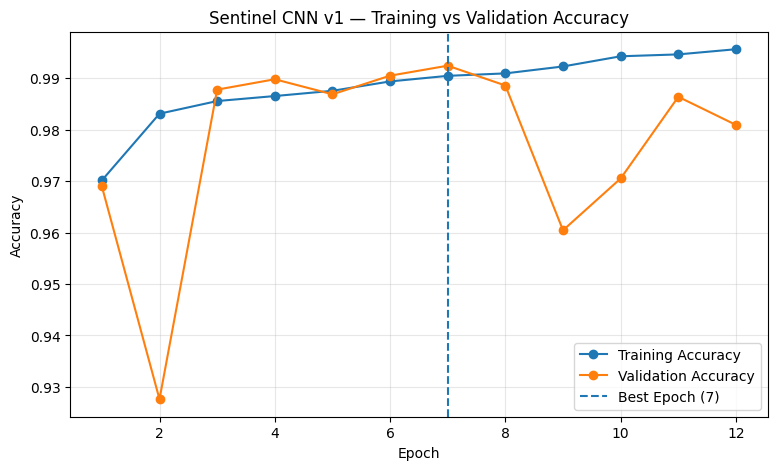

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs_range,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=7,
    linestyle="--",
    label="Best Epoch (7)"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Sentinel CNN v1 — Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**21. Saving Model**

In [24]:
import joblib
import os

# The best model already exists:
cnn_model_path = "/content/sentinel_cnn_binary_v1_best.keras"

# Save scaler
scaler_path = "/content/sentinel_cnn_scaler_v1.joblib"
joblib.dump(scaler, scaler_path)

# Save exact 77-feature order
feature_columns = list(X_train.columns)

features_path = "/content/sentinel_feature_columns_v1.joblib"
joblib.dump(feature_columns, features_path)

print("CNN artifacts saved successfully.\n")

for file in [
    cnn_model_path,
    scaler_path,
    features_path
]:
    size = os.path.getsize(file)

    if size >= 1024**2:
        print(f"{os.path.basename(file)}: {size/(1024**2):.2f} MB")
    else:
        print(f"{os.path.basename(file)}: {size/1024:.2f} KB")

CNN artifacts saved successfully.

sentinel_cnn_binary_v1_best.keras: 1.97 MB
sentinel_cnn_scaler_v1.joblib: 4.01 KB
sentinel_feature_columns_v1.joblib: 1.39 KB
